In [39]:

"""
construction_pipeline_v13.py
============================
Stage-duration prediction pipeline — city-based modeling with clean, focused
feature engineering per the v13 spec.
 
KEY CHANGES vs V12
------------------
1.  DATA CLEANING
    • All date columns parsed; 1970-01-01 treated as NaT.
    • All categorical text uppercased and stripped.
 
2.  CITY-BASED MODELING
    • Models built per City (not Division).
    • Cities with too few jobs are bundled with the nearest city by
      (job count similarity + mean total-duration similarity).
 
3.  FEATURES — SIMPLIFIED & FOCUSED
    Rolling averages:
      • CityRollingAvg10      — last 10 jobs in the same city (leakage-safe)
      • CommunityRollingAvg10 — last 10 jobs in same community within city
 
    Delay features (city-average imputation when one side is missing):
      NoRex, TreePermit, EnergyREZCheck, AtticVentingPlan, ThermalPlan,
      Developer, Engineering, FoundationRevision, SitePlan,
      HVACManualJDS, Plumbing
 
    Special:
      • ConstructionCreditDays: NULL→flag(-1), 0→0, else log1p(value)
      • GarageDrop ordinal:  No Drop=0, <1 Drop=1, 1-4 Drop=2, >4 Drop=3
      • CommunityName cyclic sin/cos encoded (by frequency rank)
      • PlanSqFt kept as-is
      • SelectionsDelay only for trim/interior stages; if either date is null → 0
      • NO DivisionName one-hot dummies
      • All seasonal + holiday features retained
 
4.  LEAKAGE-FREE everywhere — shift(1) before every rolling window.
"""
 
# ==============================================================================
# CELL 01 – Imports & Config
# ==============================================================================
import os, json, warnings, math
import numpy as np
import pandas as pd
import lightgbm as lgb
import joblib
from datetime import date, timedelta
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import TimeSeriesSplit
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
 
# ── Paths ─────────────────────────────────────────────────────────────────────
STAGE_FILE = "Stage.csv"
FACT_FILE  = "ActualV6.csv"
OUTPUT_DIR = "./output_v13"
os.makedirs(OUTPUT_DIR, exist_ok=True)
 
# ── Global constants ──────────────────────────────────────────────────────────
RANDOM_STATE   = 42
CUTOFF_DATE    = pd.Timestamp("2023-12-01")
OPTUNA_TRIALS  = 50
LOG_SPACE      = True
 
# City bundling: if a city has fewer than this many completed jobs across ALL
# stages, it gets merged with the nearest city.
MIN_CITY_JOBS  = 30
 
# ── Stage configuration ───────────────────────────────────────────────────────
STAGE_CONFIGS = {
    "foundation":  ("FoundationStartDate", "FrameDate",            "FoundationDuration"),
    "frame":       ("FrameDate",           "CorniceDate",          "FrameDuration"),
    "cornice":     ("CorniceDate",         "MechanicalDate",       "CorniceDuration"),
    "mechanicals": ("MechanicalDate",      "SheetrockDate",        "MechanicalsDuration"),
    "sheetrock":   ("SheetrockDate",       "TrimDate",             "SheetrockDuration"),
    "trim":        ("TrimDate",            "InteriorDate",         "TrimDuration"),
    "interior":    ("InteriorDate",        "ActualCompletionDate", "InteriorDuration"),
}
STAGE_ORDER   = list(STAGE_CONFIGS.keys())
DURATION_COLS = [v[2] for v in STAGE_CONFIGS.values()]
 
# ── Per-city test set (latest N jobs per city) ─────────────────────────────────
CITY_TEST_COUNTS = {
    "HOUSTON": 15, "SAN ANTONIO": 10, "AUSTIN": 10,
}
DEFAULT_TEST_COUNT = 5

print("Config ready.")
 

Config ready.


In [40]:
# ==============================================================================
# CELL 02 – Load & Rename
# ==============================================================================
def load_and_rename():
    df_stage = pd.read_csv(STAGE_FILE, low_memory=False)
    df_fact  = pd.read_csv(FACT_FILE,  low_memory=False)
 
    # Drop duplicated header row that some exports include
    for _df in [df_stage, df_fact]:
        if len(_df) > 0 and _df.iloc[0].tolist() == list(_df.columns):
            _df.drop(index=0, inplace=True)
            _df.reset_index(drop=True, inplace=True)
 
    df_stage.columns = [
        "JobNumber","WarehouseId","DivisionName","WarehouseName","StreetAddress",
        "ReleasedCompleteDate",
        "ActualFoundationDate","ActualFrameDate","ActualCorniceDate",
        "ActualMechanicalsDate","ActualSheetrockDate","ActualTrimDate",
        "ActualInteriorDate","ActualFinalDate","ActualCloseDate",
        "FourMonthAvgFoundationDate","FourMonthAvgFrameDate",
        "FourMonthAvgCorniceDate","FourMonthAvgMechanicalsDate",
        "FourMonthAvgSheetrockDate","FourMonthAvgTrimDate",
        "FourMonthAvgInteriorDate","FourMonthAvgFinalDate","FourMonthAvgCloseDate",
        "FoundationDuration","FrameDuration","CorniceDuration",
        "MechanicalsDuration","SheetrockDuration","TrimDuration",
        "InteriorDuration","FinalDuration","CloseDuration",
        "FoundationDurationAvgProj","FoundationDurationAvgDiv",
        "FrameDurationAvgProj","FrameDurationAvgDiv",
        "CorniceDurationAvgProj","CorniceDurationAvgDiv",
        "MechanicalsDurationAvgProj","MechanicalsDurationAvgDiv",
        "SheetrockDurationAvgProj","SheetrockDurationAvgDiv",
        "TrimDurationAvgProj","TrimDurationAvgDiv",
        "InteriorDurationAvgProj","InteriorDurationAvgDiv",
        "FinalDurationAvgProj","FinalDurationAvgDiv",
        "CloseDurationAvgProj","CloseDurationAvgDiv",
        "CurrentStage","LastCompletedStage","LastCompletedStageDate",
    ]
 
    df_fact.columns = [
        "JobNumber","JobReferenceNumber","State","County","City",
        "CommunityName","CommunityId",
        "Plan","Elevation","Plansqft","Lotsqft","LotType",
        "CornerLotYN","Swing","JobSwing","GarageDrop",
        "Section","Block","Lot","DivisionName",
        "ConstructionCreditDays","StageOfConstruction","StageOfConstructionId",
        "PreReleaseDate","ReleaseDate","EstimatedReleaseDate",
        "EstimatedConstructionDate","ActualConstructionDate","ActualStartDate",
        "EstimatedCompletionDate","ActualCompletionDate",
        "FoundationStartDate","FrameDate","CorniceDate","MechanicalDate",
        "SheetrockDate","TrimDate","InteriorDate",
        "CityPermitRequestedDate","CityPermitReceiveddDate",
        "CountyPermitRequesteddDate","CountyPermitReceiveddDate",
        "FoundationSentDate","FoundationReceivedDate",
        "HVACManualJDSrequestedDate","HVACManualJDSReceivedDate",
        "SelectionsRequestedDate","SelectionsReceivedDate",
        "EstimatedEscrowCloseDate","ActualEscrowCloseDate",
        "BasePrice","SalesPrice","IsRental",
        "BusinessProjectedCloseDate","PossibleCloseDate",
        "ZipCode","MarketCode","MarketName",
        "LotPremium","NegotiatingAllowance","RealtorBonus",
        "AnyAdditionalMasonryRequirement","AnyCustomRequirement","AnyCOPRequirement",
        "InventoryStatus","UnitStatus",
        "PlumbingRequestedDate","PlumbingReceivedDate",
        "SitePlanRequestedDate","SitePlanReceivedDate",
        "FoundationRevisionRequestedDate","FoundationRevisionReceivedDate",
        "EngineeringSentDate","EngineeringReceivedDate",
        "DeveloperRequestedDate","DeveloperReceivedDate",
        "ThermalPlanRequestedDate","ThermalPlanReceivedDate",
        "AtticVentingPlanRequestedDate","AtticVentingPlanReceivedDate",
        "EnergyREZCheckRequestedDate","EnergyREZCheckReceivedDate",
        "TreePermitRequestedDate","TreePermitReceivedDate",
        "CityPermitDenieddDate","CountyPermitDeniedDate",
        "PanelDate","PanelOnHoldDate","PanelOffHoldDate",
        "NoRexRequestedDate","NoRexReceivedDate",
    ]
 
    # ── Date parsing: coerce errors, replace 1970-01-01 with NaT ─────────────
    FACT_DATE_COLS = [
        "PreReleaseDate","ReleaseDate","EstimatedReleaseDate",
        "EstimatedConstructionDate","ActualConstructionDate","ActualStartDate",
        "EstimatedCompletionDate","ActualCompletionDate",
        "FoundationStartDate","FrameDate","CorniceDate","MechanicalDate",
        "SheetrockDate","TrimDate","InteriorDate",
        "CityPermitRequestedDate","CityPermitReceiveddDate",
        "CountyPermitRequesteddDate","CountyPermitReceiveddDate",
        "FoundationSentDate","FoundationReceivedDate",
        "HVACManualJDSrequestedDate","HVACManualJDSReceivedDate",
        "SelectionsRequestedDate","SelectionsReceivedDate",
        "BusinessProjectedCloseDate",
        "PlumbingRequestedDate","PlumbingReceivedDate",
        "SitePlanRequestedDate","SitePlanReceivedDate",
        "FoundationRevisionRequestedDate","FoundationRevisionReceivedDate",
        "EngineeringSentDate","EngineeringReceivedDate",
        "DeveloperRequestedDate","DeveloperReceivedDate",
        "ThermalPlanRequestedDate","ThermalPlanReceivedDate",
        "AtticVentingPlanRequestedDate","AtticVentingPlanReceivedDate",
        "EnergyREZCheckRequestedDate","EnergyREZCheckReceivedDate",
        "TreePermitRequestedDate","TreePermitReceivedDate",
        "CityPermitDenieddDate","CountyPermitDeniedDate",
        "PanelDate","PanelOnHoldDate","PanelOffHoldDate",
        "NoRexRequestedDate","NoRexReceivedDate",
    ]
    _EPOCH = pd.Timestamp("1970-01-01")
    for col in FACT_DATE_COLS:
        if col in df_fact.columns:
            s = pd.to_datetime(df_fact[col], errors="coerce")
            s[s == _EPOCH] = pd.NaT
            df_fact[col] = s
 
    # ── Categorical cleanup: UPPERCASE + strip ────────────────────────────────
    CAT_COLS = ["City","CommunityName","DivisionName","GarageDrop",
                "Swing","JobSwing","Plan","LotType","InventoryStatus",
                "UnitStatus","MarketName","State","County"]
    for col in CAT_COLS:
        if col in df_fact.columns:
            df_fact[col] = (df_fact[col].fillna("")
                            .astype(str).str.strip().str.upper())
 
    df_fact["JobReferenceNumber"] = (df_fact["JobReferenceNumber"]
                                     .astype(str).str.strip())
    df_stage["JobNumber"]         = (df_stage["JobNumber"]
                                     .astype(str).str.strip())
    df_fact["JobNumber"]          = (df_fact["JobNumber"]
                                     .astype(str).str.strip())
 
    print(f"df_stage: {df_stage.shape}  |  df_fact: {df_fact.shape}")
    return df_stage, df_fact
 
 
df_stage, df_fact = load_and_rename()
 
 

df_stage: (44601, 54)  |  df_fact: (43692, 91)


In [41]:
# ==============================================================================
# CELL 03 – Compute Durations & Clip Outliers
# ==============================================================================
def compute_durations_and_clip(df_fact):
    df = df_fact[df_fact["FoundationStartDate"] >= CUTOFF_DATE].copy()
    print(f"After {CUTOFF_DATE.date()} filter: {len(df):,} jobs")
 
    df["FoundationDuration"]  = (df["FrameDate"]            - df["FoundationStartDate"]).dt.days
    df["FrameDuration"]       = (df["CorniceDate"]          - df["FrameDate"]).dt.days
    df["CorniceDuration"]     = (df["MechanicalDate"]       - df["CorniceDate"]).dt.days
    df["MechanicalsDuration"] = (df["SheetrockDate"]        - df["MechanicalDate"]).dt.days
    df["SheetrockDuration"]   = (df["TrimDate"]             - df["SheetrockDate"]).dt.days
    df["TrimDuration"]        = (df["InteriorDate"]         - df["TrimDate"]).dt.days
    df["InteriorDuration"]    = (df["ActualCompletionDate"] - df["InteriorDate"]).dt.days
    df["TotalConstructionDuration"] = (
        (df["ActualCompletionDate"] - df["FoundationStartDate"]).dt.days)
 
    # Per-city-aware outlier clipping
    ALL_DUR_COLS   = DURATION_COLS + ["TotalConstructionDuration"]
    OUTLIER_BOUNDS = {}
    for col in ALL_DUR_COLS:
        tmp = df[df[col].notna() & (df[col] > 0)].copy()
        if len(tmp) == 0:
            continue
        glo, ghi = tmp[col].quantile(0.01), tmp[col].quantile(0.99)
        city_caps = {}
        for city, grp in tmp.groupby("City"):
            valid = grp[col].dropna()
            if len(valid) >= 20:
                city_caps[city] = max(ghi, valid.quantile(0.97) * 1.2)
        clipped = tmp[col].copy()
        for city, cap in city_caps.items():
            mask = tmp["City"] == city
            clipped.loc[mask] = tmp.loc[mask, col].clip(lower=glo, upper=cap)
        no_cap = ~tmp["City"].isin(city_caps)
        clipped.loc[no_cap] = tmp.loc[no_cap, col].clip(lower=glo, upper=ghi)
        df.loc[tmp.index, col] = clipped
        OUTLIER_BOUNDS[col] = (glo, ghi)
 
    with open(f"{OUTPUT_DIR}/outlier_bounds.json", "w", encoding="utf-8") as f:
        json.dump({k: list(v) for k, v in OUTLIER_BOUNDS.items()}, f, indent=2)
    print(f"Durations computed & clipped. Rows: {len(df):,}")
    return df, OUTLIER_BOUNDS
 
 
df, OUTLIER_BOUNDS = compute_durations_and_clip(df_fact)
 

After 2023-12-01 filter: 8,026 jobs
Durations computed & clipped. Rows: 8,026


In [42]:
# ==============================================================================
# CELL 04 – City Bundling
# ==============================================================================
def build_city_map(df, min_jobs=MIN_CITY_JOBS):
    """
    Returns city_map: {original_city: model_city}.
    Cities with < min_jobs are merged with the nearest city by:
      (1) smallest job-count difference, (2) smallest mean-total-duration diff.
    """
    city_stats = (df.groupby("City")
                    .agg(n_jobs=("JobNumber","count"),
                         mean_dur=("TotalConstructionDuration","mean"))
                    .reset_index())
 
    large = city_stats[city_stats["n_jobs"] >= min_jobs].copy()
    small = city_stats[city_stats["n_jobs"] <  min_jobs].copy()
 
    city_map = {c: c for c in large["City"]}
 
    if len(large) == 0:
        # Edge case: all cities are small – use a single global bucket
        city_map = {c: "_ALL_CITIES" for c in city_stats["City"]}
        print("WARNING: no city meets MIN_CITY_JOBS; using single global model.")
        return city_map
 
    for _, row in small.iterrows():
        # Score = normalised job-count diff + normalised duration diff
        diffs = large.copy()
        count_range = large["n_jobs"].max() - large["n_jobs"].min() + 1
        dur_range   = (large["mean_dur"].max() - large["mean_dur"].min() + 1
                       if large["mean_dur"].notna().any() else 1)
        diffs["score"] = (
            (diffs["n_jobs"] - row["n_jobs"]).abs() / count_range
            + (diffs["mean_dur"].fillna(0) - (row["mean_dur"] if pd.notna(row["mean_dur"]) else 0)).abs() / dur_range
        )
        nearest = diffs.loc[diffs["score"].idxmin(), "City"]
        city_map[row["City"]] = nearest
        print(f"  City bundle: '{row['City']}' ({int(row['n_jobs'])} jobs) "
              f"→ '{nearest}'")
 
    # cities not in stats (blank / unknown) → _UNKNOWN
    for city in df["City"].unique():
        if city not in city_map:
            if len(large):
                city_map[city] = large.loc[
                    large["n_jobs"].idxmax(), "City"]
            else:
                city_map[city] = "_ALL_CITIES"
 
    print(f"City map: {len(large)} model-cities, "
          f"{len(small)} bundled cities.")
    return city_map
 
 
city_map = build_city_map(df)
df["ModelCity"] = df["City"].map(city_map).fillna(df["City"])
 
with open(f"{OUTPUT_DIR}/city_map.json", "w") as f:
    json.dump(city_map, f, indent=2)
print("ModelCity distribution:")
print(df["ModelCity"].value_counts().head(10))
 
 

  City bundle: 'CIBOLO' (12 jobs) → 'ROSENBERG'
  City bundle: 'HURST' (18 jobs) → 'THE COLONY'
  City bundle: 'HUTTO' (23 jobs) → 'SAN MARCOS'
  City bundle: 'LAKEWOOD VILLAGE' (18 jobs) → 'MONTGOMERY'
  City bundle: 'LEAGUE CITY' (7 jobs) → 'THE COLONY'
  City bundle: 'LEANDER' (24 jobs) → 'MONTGOMERY'
  City bundle: 'LOCKHART' (16 jobs) → 'LAVON'
  City bundle: 'LUCAS' (2 jobs) → 'PROSPER'
  City bundle: 'MANOR' (2 jobs) → 'THE COLONY'
  City bundle: 'MCLENDON-CHISHOLM' (6 jobs) → 'ROSENBERG'
  City bundle: 'PFLUGERVILLE' (9 jobs) → 'FRISCO'
  City bundle: 'ROSHARON' (2 jobs) → 'THE COLONY'
  City bundle: 'TODD MISSION' (5 jobs) → 'IOWA COLONY'
  City bundle: 'VAN ALSTYNE' (26 jobs) → 'OAK POINT'
  City bundle: 'WAXAHACHIE' (23 jobs) → 'HUMBLE'
City map: 46 model-cities, 15 bundled cities.
ModelCity distribution:
ModelCity
SAN ANTONIO      788
RICHMOND         526
FULSHEAR         446
GEORGETOWN       407
MANVEL           363
KATY             336
CYPRESS          327
CELINA         

In [43]:
# ==============================================================================
# CELL 04b – Holiday Helpers  (kept from v12, no target involved)
# ==============================================================================
def _easter(year):
    a=year%19; b=year//100; c=year%100; d=b//4; e=b%4
    f=(b+8)//25; g=(b-f+1)//3; h=(19*a+b-d-g+15)%30
    i=c//4; k=c%4; l=(32+2*e+2*i-h-k)%7; m=(a+11*h+22*l)//451
    return date(year,(h+l-7*m+114)//31,((h+l-7*m+114)%31)+1)
 
 
def company_holidays(year):
    h = set()
    h.add(date(year,1,1))
    jan=pd.date_range(f"{year}-01-01",f"{year}-01-31",freq="W-MON"); h.add(jan[2].date())
    h.add(_easter(year)-timedelta(days=2))
    may=pd.date_range(f"{year}-05-01",f"{year}-05-31",freq="W-MON"); h.add(may[-1].date())
    h.add(date(year,7,4))
    sep=pd.date_range(f"{year}-09-01",f"{year}-09-30",freq="W-MON"); h.add(sep[0].date())
    nov=pd.date_range(f"{year}-11-01",f"{year}-11-30",freq="W-THU"); tg=nov[3].date()
    h.add(tg); h.add(tg+timedelta(days=1))
    for d_ in range(9): h.add(date(year,12,24)+timedelta(days=d_))
    return h
 
 
HOLIDAYS         = {y: company_holidays(y) for y in range(2023, 2032)}
ALL_HOLIDAY_DATES = set()
for _hset in HOLIDAYS.values():
    ALL_HOLIDAY_DATES.update(_hset)
 
 
def holidays_in_window(start, end):
    if pd.isna(start) or pd.isna(end): return 0
    s=pd.to_datetime(start).date(); e=pd.to_datetime(end).date()
    if e < s: return 0
    return sum(1 for y in range(s.year, e.year+1)
               for h in HOLIDAYS.get(y, []) if s <= h <= e)
 
 
def workdays_in_window(start, end):
    if pd.isna(start) or pd.isna(end): return 0
    s=pd.to_datetime(start).date(); e=pd.to_datetime(end).date()
    if e < s: return 0
    return int(np.busday_count(s, e+timedelta(days=1)))
 
 
def weekends_in_window(start, end):
    if pd.isna(start) or pd.isna(end): return 0
    return max(0,(pd.to_datetime(end)-pd.to_datetime(start)).days+1
               -workdays_in_window(start,end))
 
 
def days_to_next_holiday(dt):
    if pd.isna(dt): return 30
    d_=pd.to_datetime(dt).date()
    for i in range(1,60):
        if (d_+timedelta(days=i)) in ALL_HOLIDAY_DATES: return i
    return 60
 
 
def holidays_in_next_n_days(dt, n=30):
    if pd.isna(dt): return 0
    d_=pd.to_datetime(dt).date()
    return sum(1 for i in range(1,n+1)
               if (d_+timedelta(days=i)) in ALL_HOLIDAY_DATES)
 
 
def is_thanksgiving_week(dt):
    if pd.isna(dt): return 0
    d_=pd.to_datetime(dt).date()
    if d_.month!=11: return 0
    nov=pd.date_range(f"{d_.year}-11-01",f"{d_.year}-11-30",freq="W-THU")
    tg=nov[3].date(); ws=tg-timedelta(days=tg.weekday()); we=ws+timedelta(days=6)
    return int(ws<=d_<=we)
 
 
def is_christmas_week(dt):
    if pd.isna(dt): return 0
    d_=pd.to_datetime(dt).date()
    return int(d_ in ALL_HOLIDAY_DATES and (d_.month==12 or (d_.month==1 and d_.day==1)))
 
 
def days_to_year_end(dt):
    if pd.isna(dt): return 180
    d_=pd.to_datetime(dt).date()
    return max(0,(date(d_.year,12,31)-d_).days)
 
 
SEASON_ENC = {"Spring":0,"Summer":1,"Fall":2,"Winter":3,"Unknown":-1}
 
 
def get_season(dt):
    if pd.isna(dt): return "Unknown",0,0
    dt=pd.to_datetime(dt); m=dt.month
    if m in [3,4,5]:     name="Spring"; s=date(dt.year,3,1);  se=date(dt.year,5,31)
    elif m in [6,7,8]:   name="Summer"; s=date(dt.year,6,1);  se=date(dt.year,8,31)
    elif m in [9,10,11]: name="Fall";   s=date(dt.year,9,1);  se=date(dt.year,11,30)
    else:
        name="Winter"
        s =date(dt.year,12,1) if m==12 else date(dt.year-1,12,1)
        se=date(dt.year+1,2,28) if m==12 else date(dt.year,2,28)
    return name, max(0,(dt.date()-s).days), max(0,(se-dt.date()).days)
 
 
print("Holiday helpers ready.")
 

Holiday helpers ready.


In [44]:
 
# ==============================================================================
# CELL 05 – Static Feature Engineering  (no target leakage)
# ==============================================================================
def compute_delay_days_city_avg(df, req_col, rec_col, out_col):
    """
    Compute delay = rec - req (days, clipped ≥ 0).
    If EITHER side is missing (NaT), use the city-level mean of non-null pairs
    for that row's city, instead of filling with zero.
    """
    req = pd.to_datetime(df[req_col], errors="coerce")
    rec = pd.to_datetime(df[rec_col], errors="coerce")
 
    raw_delay = (rec - req).dt.days
 
    # Replace negatives with NaN (bad data)
    raw_delay = raw_delay.where(raw_delay >= 0, other=np.nan)
 
    # City average from valid pairs only
    city_avg = (raw_delay.groupby(df["City"])
                         .transform(lambda x: x.mean()))
 
    # Where either date is missing, use city avg; if city avg is also NaN use global avg
    global_avg = float(raw_delay.mean()) if raw_delay.notna().any() else 0.0
    either_missing = req.isna() | rec.isna()
    filled = raw_delay.copy()
    filled[either_missing] = city_avg[either_missing].fillna(global_avg)
    df[out_col] = filled.fillna(global_avg).clip(lower=0)
    return df
 
 
def encode_construction_credit(series):
    """
    NULL  → -1   (flag: credit info not available, may take more days)
    0     →  0   (no credit, likely faster)
    >0    → log1p(value) as float (treat proportionally)
    """
    result = pd.to_numeric(series, errors="coerce")
    encoded = np.where(result.isna(), -1.0,
              np.where(result == 0, 0.0,
                       np.log1p(result.clip(lower=0))))
    return pd.Series(encoded, index=series.index)
 
 
def garage_drop_ordinal(series):
    """
    No Drop   → 0
    <1 Drop   → 1
    1-4 Drop  → 2
    >4 Drop   → 3
    """
    def _map(v):
        v = str(v).strip().upper()
        if ">4" in v or "> 4" in v:       return 3
        if "1-4" in v or "1 - 4" in v:    return 2
        if "<1" in v or "< 1" in v:        return 1
        return 0   # "NO DROP" or anything unrecognised → 0
    return series.apply(_map).astype(int)
 
 
def community_cyclic_encode(df, community_col="CommunityName"):
    """
    Cyclic sin/cos encoding for community, based on frequency rank.
    Rank 0 (most common) → angle 0; rarer communities spread around the circle.
    """
    freq = df[community_col].value_counts()
    rank = freq.rank(method="first", ascending=False) - 1   # 0-indexed
    n    = max(len(rank), 1)
    angle = (df[community_col].map(rank).fillna(n - 1) / n) * 2 * math.pi
    df["CommunityNameSin"] = np.sin(angle)
    df["CommunityNameCos"] = np.cos(angle)
    return df
 
 
def engineer_static_features(df):
    """
    All features that do NOT require fitting on the target variable.
    Safe to compute globally before any train/test split.
    """
    # ── PlanSqFt ─────────────────────────────────────────────────────────────
    df["Plansqft"] = pd.to_numeric(df["Plansqft"], errors="coerce")
    fill_plansqft  = float(df["Plansqft"].median())
    df["Plansqft"] = df["Plansqft"].fillna(fill_plansqft).clip(lower=1)
    # Keep raw PlanSqFt as requested
    df["PlanSqFt"] = df["Plansqft"]   # canonical alias
 
    # ── ConstructionCreditDays ────────────────────────────────────────────────
    df["ConstructionCreditEnc"] = encode_construction_credit(
        df["ConstructionCreditDays"])
 
    # ── GarageDrop ordinal ────────────────────────────────────────────────────
    df["GarageDropOrd"] = garage_drop_ordinal(df["GarageDrop"])
 
    # ── Community cyclic ─────────────────────────────────────────────────────
    df = community_cyclic_encode(df, "CommunityName")
 
    # ── Plan parsing ──────────────────────────────────────────────────────────
    df["Plan"] = df["Plan"].replace("", "UNKNOWN")
    def split_plan(p):
        if p in ("UNKNOWN", "NAN", ""): return np.nan, "UNKNOWN"
        if p[-1].isalpha(): return pd.to_numeric(p[:-1], errors="coerce"), p[-1]
        return pd.to_numeric(p, errors="coerce"), ""
    plan_parsed     = df["Plan"].apply(split_plan)
    df["PlanCode"]  = plan_parsed.apply(lambda x: x[0]).fillna(
        plan_parsed.apply(lambda x: x[0]).median())
    df["PlanLetter"]= plan_parsed.apply(lambda x: x[1])
 
    # ── Elevation ─────────────────────────────────────────────────────────────
    df["Elevation"]        = pd.to_numeric(df["Elevation"], errors="coerce").fillna(0)
    df["ElevationFamily"]  = (df["Elevation"] // 10).astype(int)
    df["ElevationVariant"] = (df["Elevation"] % 10).astype(int)
 
    # ── Ordinal encoders for city, ModelCity, Swing ───────────────────────────
    encoders = {}
    for col, key in [("City","city"), ("ModelCity","model_city"),
                     ("Swing","swing"), ("PlanLetter","plan_letter")]:
        enc = OrdinalEncoder(handle_unknown="use_encoded_value",
                             unknown_value=-1, dtype=np.int32)
        enc.fit(df[[col]])
        df[f"{key.replace('_','').title()}Enc"] = enc.transform(df[[col]]).ravel()
        encoders[key] = enc
 
    # CommunityName ordinal (for potential direct use)
    enc_comm = OrdinalEncoder(handle_unknown="use_encoded_value",
                              unknown_value=-1, dtype=np.int32)
    enc_comm.fit(df[["CommunityName"]])
    df["CommunityEnc"] = enc_comm.transform(df[["CommunityName"]]).ravel()
    encoders["community"] = enc_comm
 
    # Interaction: City × PlanCode
    df["CityPlan"] = df["City"].astype(str) + "_" + df["PlanCode"].astype(int).astype(str)
    enc_cp = OrdinalEncoder(handle_unknown="use_encoded_value",
                            unknown_value=-1, dtype=np.int32)
    enc_cp.fit(df[["CityPlan"]])
    df["CityPlanEnc"] = enc_cp.transform(df[["CityPlan"]]).ravel()
    encoders["cityplan"] = enc_cp
 
    # ── Season interaction: ModelCity × month ──────────────────────────────
    df["_StartMonth_tmp"] = pd.to_datetime(
        df["FoundationStartDate"], errors="coerce").dt.month.fillna(1)
    df["CityMonth"] = df["ModelCity"] + "_" + df["_StartMonth_tmp"].astype(int).astype(str)
 
    def _season(m):
        m = int(m)
        return ("Spring" if m in [3,4,5] else
                "Summer" if m in [6,7,8] else
                "Fall"   if m in [9,10,11] else "Winter")
    df["CitySeason"] = df["ModelCity"] + "_" + df["_StartMonth_tmp"].apply(_season)
    for key, col in [("citymonth","CityMonth"),("cityseason","CitySeason")]:
        enc = OrdinalEncoder(handle_unknown="use_encoded_value",
                             unknown_value=-1, dtype=np.int32)
        enc.fit(df[[col]])
        df[f"{col}Enc"] = enc.transform(df[[col]]).ravel()
        encoders[key] = enc
    df.drop(columns=["_StartMonth_tmp"], inplace=True)
 
    # ── Corner lot ─────────────────────────────────────────────────────────
    df["CornerLot"] = df["CornerLotYN"].map(
        lambda x: 1 if str(x).strip().upper() in ["Y","YES","1","TRUE"] else 0)
 
    # ── Delay features with city-average imputation ───────────────────────────
    DELAY_PAIRS = [
        # (req_col, rec_col, out_col)
        ("NoRexRequestedDate",             "NoRexReceivedDate",              "NoRexDelayDays"),
        ("TreePermitRequestedDate",        "TreePermitReceivedDate",        "TreePermitDelayDays"),
        ("EnergyREZCheckRequestedDate",    "EnergyREZCheckReceivedDate",    "EnergyREZCheckDelayDays"),
        ("AtticVentingPlanRequestedDate",  "AtticVentingPlanReceivedDate",  "AtticVentingDelayDays"),
        ("ThermalPlanRequestedDate",       "ThermalPlanReceivedDate",       "ThermalPlanDelayDays"),
        ("DeveloperRequestedDate",         "DeveloperReceivedDate",         "DeveloperDelayDays"),
        ("EngineeringSentDate",            "EngineeringReceivedDate",       "EngineeringDelayDays"),
        ("FoundationRevisionRequestedDate","FoundationRevisionReceivedDate","FoundationRevisionDelayDays"),
        ("SitePlanRequestedDate",          "SitePlanReceivedDate",          "SitePlanDelayDays"),
        ("HVACManualJDSrequestedDate",     "HVACManualJDSReceivedDate",     "HVACManualJDSDelayDays"),
        ("PlumbingRequestedDate",          "PlumbingReceivedDate",          "PlumbingDelayDays"),
    ]
    for req, rec, out in DELAY_PAIRS:
        if req in df.columns and rec in df.columns:
            df = compute_delay_days_city_avg(df, req, rec, out)
        else:
            df[out] = 0.0
 
    # SelectionsDelay is stage-specific (trim/interior only) — compute raw here
    # actual stage-level gating happens in build_stage_df
    if ("SelectionsRequestedDate" in df.columns and
            "SelectionsReceivedDate" in df.columns):
        req_s = pd.to_datetime(df["SelectionsRequestedDate"], errors="coerce")
        rec_s = pd.to_datetime(df["SelectionsReceivedDate"],  errors="coerce")
        raw_sd = (rec_s - req_s).dt.days
        raw_sd = raw_sd.where(raw_sd >= 0, other=np.nan)
        # Do NOT city-impute here; missing = 0 (set in build_stage_df)
        df["SelectionsDelayRaw"] = raw_sd
    else:
        df["SelectionsDelayRaw"] = np.nan
 
    # ── Leakage-free division/city aggregate features ─────────────────────────
    # Sort by start date so expanding/rolling are always time-ordered
    df = df.sort_values("FoundationStartDate").reset_index(drop=True)
 
    df["City_ExpandingMean"] = (
        df.groupby("ModelCity")["TotalConstructionDuration"]
        .transform(lambda x: x.shift(1).expanding().mean())
    ).fillna(df["TotalConstructionDuration"].median())
 
    df["City_ExpandingStd"] = (
        df.groupby("ModelCity")["TotalConstructionDuration"]
        .transform(lambda x: x.shift(1).expanding().std())
    ).fillna(df["TotalConstructionDuration"].std())
 
    global_median = df["TotalConstructionDuration"].median()
    df["City_Velocity"] = np.where(
        df["City_ExpandingMean"] > 0,
        global_median / df["City_ExpandingMean"],
        1.0)
 
    df["City_Trend"] = (
        df.groupby("ModelCity")["TotalConstructionDuration"]
        .transform(lambda x: x.shift(1).rolling(50, min_periods=5).mean())
    ).fillna(df["City_ExpandingMean"])
 
    df["City_Lag1Duration"] = (
        df.groupby("ModelCity")["TotalConstructionDuration"]
        .transform(lambda x: x.shift(1))
    ).fillna(df["City_ExpandingMean"])
 
    LEAKAGE_FREE_CITY_FEATURES = [
        "City_ExpandingMean","City_ExpandingStd",
        "City_Velocity","City_Trend","City_Lag1Duration",
    ]
 
    # ── Assemble SHARED_FEATURES list ─────────────────────────────────────────
    SHARED_FEATURES = [
        # Job physical
        "PlanSqFt",
        "PlanCode","PlanletterencEnc",
        "ElevationFamily","ElevationVariant",
        "CornerLot",
        # Garage
        "GarageDropOrd",
        # Swing
        "SwingEnc",
        # Credit
        "ConstructionCreditEnc",
        # City / community
        "CityEnc","ModelcityEnc","CommunityEnc",
        "CommunityNameSin","CommunityNameCos",
        "CityPlanEnc",
        "CityMonthEnc","CitySeasonEnc",
        # City-level leakage-free aggregates
    ] + LEAKAGE_FREE_CITY_FEATURES + [
        # Delay features (all 11 workflows)
        "NoRexDelayDays",
        "TreePermitDelayDays",
        "EnergyREZCheckDelayDays",
        "AtticVentingDelayDays",
        "ThermalPlanDelayDays",
        "DeveloperDelayDays",
        "EngineeringDelayDays",
        "FoundationRevisionDelayDays",
        "SitePlanDelayDays",
        "HVACManualJDSDelayDays",
        "PlumbingDelayDays",
    ]
 
    SHARED_FEATURES = [f for f in SHARED_FEATURES if f in df.columns]
    print(f"Static features engineered. SHARED_FEATURES: {len(SHARED_FEATURES)}")
    return df, SHARED_FEATURES, encoders
 
 
df, SHARED_FEATURES, encoders = engineer_static_features(df)
 
# Save encoder bundle for inference
encoder_bundle = dict(encoders)
encoder_bundle["plansqft_fill"] = float(df["PlanSqFt"].median())
joblib.dump(encoder_bundle, f"{OUTPUT_DIR}/encoder_bundle.pkl")
 

Static features engineered. SHARED_FEATURES: 32


['./output_v13/encoder_bundle.pkl']

In [45]:

# ==============================================================================
# CELL 05b – Train / Test Split  (per-city, latest jobs)
# ==============================================================================
def build_test_split(df):
    ALL_END_COLS = ["FrameDate","CorniceDate","MechanicalDate",
                    "SheetrockDate","TrimDate","InteriorDate","ActualCompletionDate"]
    fully_complete = df.dropna(
        subset=["FoundationStartDate"] + ALL_END_COLS
    ).sort_values("FoundationStartDate")
 
    print(f"Fully completed jobs: {len(fully_complete):,}")
 
    test_ids = set()
    for city in df["ModelCity"].unique():
        n = CITY_TEST_COUNTS.get(city, DEFAULT_TEST_COUNT)
        city_jobs = fully_complete[fully_complete["ModelCity"] == city]
        take = min(n, len(city_jobs))
        if take == 0:
            print(f"  WARNING: ModelCity '{city}' has 0 completed jobs")
            continue
        test_ids.update(city_jobs.tail(take)["JobNumber"].tolist())
 
    train_ids = set(df["JobNumber"]) - test_ids
    print(f"Test: {len(test_ids)} jobs  |  Train: {len(train_ids)} jobs")
    return test_ids, train_ids
 
 
test_job_ids, train_job_ids = build_test_split(df)
 
 

Fully completed jobs: 7,789
Test: 240 jobs  |  Train: 7786 jobs


In [46]:

# ==============================================================================
# CELL 06 – Per-Stage Feature DataFrames  (leakage-free)
# ==============================================================================
STAGE_SPECIFIC_FEATURES = [
    # Calendar
    "StartMonth","StartQuarter","StartDayOfWeek","StartYear","StartWeekOfYear",
    "IsSummer","IsWinter","IsSpring","IsFall","IsHolidayMonth",
    "SeasonEnc","DaysIntoSeason",
    # Holiday proximity
    "DaysToNextHoliday","HolidaysNext14d","HolidaysNext30d",
    "IsThanksgivingWeek","IsChristmasWeek","DaysToYearEnd","IsQ4","IsNovDec",
    # Rolling averages (city & community, last 10)
    "CityRollingAvg10","CommunityRollingAvg10",
    # Holiday window
    "WorkdaysInAvgWindow","WeekendsInAvgWindow","HolidaysInAvgWindow",
    "NetWorkdaysAvgWindow","WeekendRatioAvg",
    # Prior stage durations (safe: earlier stages completed before this one)
    "PriorFoundationDur","PriorFrameDur","PriorCorniceDur",
    "PriorMechanicalsDur","PriorSheetrockDur","PriorTrimDur",
    "PriorStagesCompleted","PriorStageCumDays",
    # Selections delay (trim/interior only; 0 for others)
    "SelectionsDelayDays",
]
 
FEATURES = STAGE_SPECIFIC_FEATURES + SHARED_FEATURES
 
PRIOR_STAGE_DUR_COLS = {
    "foundation":  [],
    "frame":       ["FoundationDuration"],
    "cornice":     ["FoundationDuration","FrameDuration"],
    "mechanicals": ["FoundationDuration","FrameDuration","CorniceDuration"],
    "sheetrock":   ["FoundationDuration","FrameDuration","CorniceDuration","MechanicalsDuration"],
    "trim":        ["FoundationDuration","FrameDuration","CorniceDuration","MechanicalsDuration","SheetrockDuration"],
    "interior":    ["FoundationDuration","FrameDuration","CorniceDuration","MechanicalsDuration","SheetrockDuration","TrimDuration"],
}
 
# Stages where SelectionsDelay is allowed
SELECTIONS_STAGES = {"trim", "interior"}
 
 
def build_stage_df(df, stage, start_col, end_col, dur_col, test_ids):
    req_cols = (
        ["JobNumber","CommunityId","CommunityName","ModelCity","City",
         "DivisionName","PlanLetter","Swing",
         start_col, end_col, dur_col,
         "SelectionsDelayRaw"]
        + SHARED_FEATURES
        + ["FoundationDuration","FrameDuration","CorniceDuration",
           "MechanicalsDuration","SheetrockDuration","TrimDuration"]
    )
    req_cols = list(dict.fromkeys(req_cols))
    d = df[[c for c in req_cols if c in df.columns]].dropna(
        subset=[start_col, end_col, dur_col]).copy()
    d = d[d[dur_col] > 0].copy().sort_values(start_col).reset_index(drop=True)
 
    # ── Calendar features ─────────────────────────────────────────────────────
    dt = pd.to_datetime(d[start_col])
    d["StartMonth"]      = dt.dt.month
    d["StartQuarter"]    = dt.dt.quarter
    d["StartDayOfWeek"]  = dt.dt.dayofweek
    d["StartYear"]       = dt.dt.year
    d["StartWeekOfYear"] = dt.dt.isocalendar().week.astype(int)
    d["IsSummer"]        = dt.dt.month.isin([6,7,8]).astype(int)
    d["IsWinter"]        = dt.dt.month.isin([12,1,2]).astype(int)
    d["IsSpring"]        = dt.dt.month.isin([3,4,5]).astype(int)
    d["IsFall"]          = dt.dt.month.isin([9,10,11]).astype(int)
    d["IsHolidayMonth"]  = dt.dt.month.isin([12,1]).astype(int)
    d["IsQ4"]            = dt.dt.month.isin([10,11,12]).astype(int)
    d["IsNovDec"]        = dt.dt.month.isin([11,12]).astype(int)
 
    sd                   = d[start_col].apply(get_season)
    d["SeasonEnc"]       = sd.apply(lambda x: SEASON_ENC.get(x[0],-1))
    d["DaysIntoSeason"]  = sd.apply(lambda x: x[1])
 
    # ── Holiday proximity ─────────────────────────────────────────────────────
    _sd = pd.to_datetime(d[start_col])
    d["DaysToNextHoliday"]  = _sd.apply(days_to_next_holiday)
    d["HolidaysNext14d"]    = _sd.apply(lambda x: holidays_in_next_n_days(x, 14))
    d["HolidaysNext30d"]    = _sd.apply(lambda x: holidays_in_next_n_days(x, 30))
    d["IsThanksgivingWeek"] = _sd.apply(is_thanksgiving_week)
    d["IsChristmasWeek"]    = _sd.apply(is_christmas_week)
    d["DaysToYearEnd"]      = _sd.apply(days_to_year_end)
 
    # ── Rolling averages — city and community (last 10, shift=1, leakage-safe)
    d["CityRollingAvg10"] = (
        d.groupby("ModelCity")[dur_col]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
    ).fillna(d[dur_col].median())
 
    d["CommunityRollingAvg10"] = (
        d.groupby(["ModelCity","CommunityId"])[dur_col]
        .transform(lambda x: x.shift(1).rolling(10, min_periods=3).mean())
    ).fillna(d["CityRollingAvg10"])   # fallback to city rolling avg
 
    # ── Window workday/weekend/holiday features ───────────────────────────────
    est_end = pd.to_datetime(d[start_col]) + pd.to_timedelta(
        d["CityRollingAvg10"].round().astype(int), unit="D")
    d["WorkdaysInAvgWindow"]  = [workdays_in_window(s, e)
                                  for s, e in zip(d[start_col], est_end)]
    d["WeekendsInAvgWindow"]  = [weekends_in_window(s, e)
                                  for s, e in zip(d[start_col], est_end)]
    d["HolidaysInAvgWindow"]  = [holidays_in_window(s, e)
                                  for s, e in zip(d[start_col], est_end)]
    d["NetWorkdaysAvgWindow"] = (d["WorkdaysInAvgWindow"]
                                  - d["HolidaysInAvgWindow"]).clip(lower=1)
    d["WeekendRatioAvg"]      = (d["WeekendsInAvgWindow"]
                                  / (d["WorkdaysInAvgWindow"] + 1))
 
    # ── Prior stage durations ─────────────────────────────────────────────────
    _prior_cols   = PRIOR_STAGE_DUR_COLS.get(stage, [])
    _all_src      = ["FoundationDuration","FrameDuration","CorniceDuration",
                     "MechanicalsDuration","SheetrockDuration","TrimDuration"]
    _all_names    = ["PriorFoundationDur","PriorFrameDur","PriorCorniceDur",
                     "PriorMechanicalsDur","PriorSheetrockDur","PriorTrimDur"]
    for src, name in zip(_all_src, _all_names):
        if src in _prior_cols and src in d.columns:
            d[name] = d[src].fillna(d[src].median())
        else:
            d[name] = 0.0
    d["PriorStagesCompleted"] = len(_prior_cols)
    if _prior_cols:
        cum_cols = [f"Prior{c.replace('Duration','Dur')}" for c in _prior_cols]
        d["PriorStageCumDays"] = d[[c for c in cum_cols if c in d.columns]].sum(axis=1)
    else:
        d["PriorStageCumDays"] = 0.0
 
    # ── SelectionsDelay (trim & interior only; else 0) ────────────────────────
    if stage in SELECTIONS_STAGES:
        # If either date was null, SelectionsDelayRaw is NaN → set to 0
        d["SelectionsDelayDays"] = d["SelectionsDelayRaw"].fillna(0).clip(lower=0)
    else:
        d["SelectionsDelayDays"] = 0.0
 
    print(f"  [{stage:<14}] {len(d):>4} rows | "
          f"train={len(d[~d['JobNumber'].isin(test_ids)])} "
          f"test={d['JobNumber'].isin(test_ids).sum()}")
    return d
 
 
stage_dfs = {}
for stage, (start_col, end_col, dur_col) in STAGE_CONFIGS.items():
    stage_dfs[stage] = build_stage_df(
        df, stage, start_col, end_col, dur_col, test_job_ids)
 
# Save full feature list
with open(f"{OUTPUT_DIR}/stage_features.json", "w") as f:
    json.dump({s: FEATURES for s in STAGE_ORDER}, f, indent=2)
print(f"\nAll stage DFs built. Total features: {len(FEATURES)}")
 
 

  [foundation    ] 7938 rows | train=7699 test=239
  [frame         ] 7735 rows | train=7500 test=235
  [cornice       ] 8008 rows | train=7768 test=240
  [mechanicals   ] 7933 rows | train=7696 test=237
  [sheetrock     ] 7923 rows | train=7683 test=240
  [trim          ] 7744 rows | train=7505 test=239
  [interior      ] 7859 rows | train=7619 test=240

All stage DFs built. Total features: 68


In [47]:
# ==============================================================================
# CELL 07 – Optuna Tuning with TimeSeriesSplit
# ==============================================================================
def tune_lgbm(stage, d, dur_col, n_trials=OPTUNA_TRIALS):
    avail_feats = [f for f in FEATURES if f in d.columns]
    train_d     = d[~d["JobNumber"].isin(test_job_ids)].copy()
    if len(train_d) < 40:
        print(f"  [{stage}] too few rows for tuning – using defaults")
        return {}
 
    tscv  = TimeSeriesSplit(n_splits=5)
    X_all = train_d[avail_feats].fillna(0).values
    y_all = (np.log1p(train_d[dur_col]).values if LOG_SPACE
             else train_d[dur_col].values)
    idx   = np.arange(len(train_d))
 
    def objective(trial):
        params = {
            "n_estimators":       trial.suggest_int("n_estimators", 200, 800),
            "learning_rate":      trial.suggest_float("learning_rate", 0.02, 0.15, log=True),
            "num_leaves":         trial.suggest_int("num_leaves", 15, 127),
            "min_child_samples":  trial.suggest_int("min_child_samples", 10, 60),
            "subsample":          trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":          trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
            "reg_lambda":         trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
            "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1,
        }
        scores = []
        for tr_idx, va_idx in tscv.split(idx):
            m = lgb.LGBMRegressor(**params)
            m.fit(X_all[tr_idx], y_all[tr_idx], eval_set=[(X_all[va_idx], y_all[va_idx])],
                  callbacks=[lgb.early_stopping(40, verbose=False),
                              lgb.log_evaluation(-1)])
            pred = m.predict(X_all[va_idx])
            if LOG_SPACE:
                scores.append(mean_absolute_error(
                    np.expm1(y_all[va_idx]), np.expm1(pred)))
            else:
                scores.append(mean_absolute_error(y_all[va_idx], pred))
        return float(np.mean(scores))
 
    study = optuna.create_study(direction="minimize",
                                sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    print(f"  [{stage}] best CV MAE={study.best_value:.2f}d  "
          f"params={study.best_params}")
    return study.best_params
 
 
best_params = {}
for stage, (_, _, dur_col) in STAGE_CONFIGS.items():
    print(f"Tuning {stage}...")
    best_params[stage] = tune_lgbm(stage, stage_dfs[stage], dur_col)
 
with open(f"{OUTPUT_DIR}/best_params.json", "w") as f:
    json.dump(best_params, f, indent=2)
 
 

Tuning foundation...
  [foundation] best CV MAE=3.37d  params={'n_estimators': 661, 'learning_rate': 0.024469793249204883, 'num_leaves': 58, 'min_child_samples': 46, 'subsample': 0.611119069728466, 'colsample_bytree': 0.5041056338684389, 'reg_alpha': 0.0024756411388530105, 'reg_lambda': 0.0138304648153433}
Tuning frame...
  [frame] best CV MAE=2.27d  params={'n_estimators': 222, 'learning_rate': 0.06702110116646762, 'num_leaves': 15, 'min_child_samples': 10, 'subsample': 0.8278074101951043, 'colsample_bytree': 0.5026869499542164, 'reg_alpha': 0.5100791655167443, 'reg_lambda': 0.002491163453972334}
Tuning cornice...
  [cornice] best CV MAE=4.34d  params={'n_estimators': 678, 'learning_rate': 0.03527116623126441, 'num_leaves': 16, 'min_child_samples': 60, 'subsample': 0.9891918754931983, 'colsample_bytree': 0.7643944775873388, 'reg_alpha': 0.0061561773145916016, 'reg_lambda': 0.03255819373964033}
Tuning mechanicals...
  [mechanicals] best CV MAE=3.32d  params={'n_estimators': 561, 'learn

In [ ]:
# ==============================================================================
# CELL 08 – Train per-City Models with proper validation (fixed)
# ==============================================================================

def train_stage_models(stage, d, start_col, dur_col, params):
    avail_feats = [f for f in FEATURES if f in d.columns]
    test_mask   = d["JobNumber"].isin(test_job_ids)
    # Sort by the stage's start date to ensure chronological order
    train_d     = d[~test_mask].copy().sort_values(start_col)
    test_d      = d[test_mask & d[dur_col].notna()].copy()

    default_params = {
        "n_estimators": 400, "learning_rate": 0.05,
        "num_leaves": 63,    "min_child_samples": 20,
        "subsample": 0.8,    "colsample_bytree": 0.8,
        "reg_alpha": 0.1,    "reg_lambda": 1.0,
        "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1,
    }
    p = {**default_params, **params}

    results   = {}
    city_models = {}

    # --- Split training data into train + validation (chronological) ---
    n_train = len(train_d)
    n_val = max(1, int(0.2 * n_train))   # at least 1 sample
    val_d = train_d.tail(n_val)
    tr_d  = train_d.head(n_train - n_val)

    # --- Global model (trained on tr_d, early stop on val_d) ---
    X_tr = tr_d[avail_feats].fillna(0)
    y_tr = np.log1p(tr_d[dur_col]) if LOG_SPACE else tr_d[dur_col]
    X_val = val_d[avail_feats].fillna(0)
    y_val = np.log1p(val_d[dur_col]) if LOG_SPACE else val_d[dur_col]

    global_model = lgb.LGBMRegressor(**p)
    global_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(-1)]
    )

    joblib.dump(global_model, f"{OUTPUT_DIR}/model_{stage}.pkl")

    # --- Evaluate global model on the real test set ---
    if len(test_d):
        pred_raw = global_model.predict(test_d[avail_feats].fillna(0))
        preds    = np.expm1(pred_raw) if LOG_SPACE else pred_raw
        mae      = mean_absolute_error(test_d[dur_col], preds)
        bias     = float(np.mean(preds - test_d[dur_col]))
        print(f"  [{stage:<14}] GLOBAL   MAE={mae:.1f}d  Bias={bias:+.1f}d  "
              f"n_test={len(test_d)}")
        results["global"] = {"mae": mae, "bias": bias, "n": len(test_d)}

    # --- Per-city models (trained on city-specific tr_d, early stop on val_d) ---
    MIN_CITY_TRAIN = 40
    for city, city_grp in tr_d.groupby("ModelCity"):
        if len(city_grp) < MIN_CITY_TRAIN:
            continue

        city_val = val_d[val_d["ModelCity"] == city]
        city_test = test_d[test_d["ModelCity"] == city]

        X_c = city_grp[avail_feats].fillna(0)
        y_c = np.log1p(city_grp[dur_col]) if LOG_SPACE else city_grp[dur_col]

        city_model = lgb.LGBMRegressor(**p)
        if len(city_val):
            X_cv = city_val[avail_feats].fillna(0)
            y_cv = np.log1p(city_val[dur_col]) if LOG_SPACE else city_val[dur_col]
            city_model.fit(
                X_c, y_c,
                eval_set=[(X_cv, y_cv)],
                callbacks=[lgb.early_stopping(50, verbose=False),
                           lgb.log_evaluation(-1)]
            )
        else:
            city_model.fit(X_c, y_c)

        safe = city.replace(" ", "_").replace("/", "_")
        joblib.dump(city_model, f"{OUTPUT_DIR}/model_{stage}_{safe}.pkl")
        city_models[city] = city_model

        if len(city_test):
            pred_raw_c = city_model.predict(city_test[avail_feats].fillna(0))
            preds_c    = np.expm1(pred_raw_c) if LOG_SPACE else pred_raw_c
            mae_c      = mean_absolute_error(city_test[dur_col], preds_c)
            bias_c     = float(np.mean(preds_c - city_test[dur_col]))
            results[city] = {"mae": mae_c, "bias": bias_c, "n": len(city_test)}
            print(f"  [{stage:<14}] city={city:<20} "
                  f"MAE={mae_c:.1f}d  Bias={bias_c:+.1f}d  "
                  f"n_test={len(city_test)}")

    return global_model, city_models, results

# ----- Re-run training with corrected function -----
final_global_models = {}
final_city_models   = {}
all_stage_results   = {}

for stage, (start_col, end_col, dur_col) in STAGE_CONFIGS.items():
    print(f"\n=== Training {stage.upper()} ===")
    gm, cm, res = train_stage_models(
        stage, stage_dfs[stage], start_col, dur_col, best_params.get(stage, {}))
    final_global_models[stage] = gm
    final_city_models[stage]   = cm
    all_stage_results[stage]   = res

# Save model types
with open(f"{OUTPUT_DIR}/model_types.json", "w") as f:
    json.dump({s: "lgb" for s in STAGE_ORDER}, f, indent=2)

print("\nAll models trained and saved with proper validation.")


=== Training FOUNDATION ===
  [foundation    ] GLOBAL   MAE=2.8d  Bias=-0.6d  n_test=239
  [foundation    ] city=AUSTIN               MAE=3.8d  Bias=-3.3d  n_test=10
  [foundation    ] city=BASTROP              MAE=1.0d  Bias=+1.0d  n_test=5
  [foundation    ] city=BOERNE               MAE=3.5d  Bias=-3.5d  n_test=5
  [foundation    ] city=BULVERDE             MAE=3.7d  Bias=-3.7d  n_test=5
  [foundation    ] city=CASTROVILLE          MAE=4.5d  Bias=-1.4d  n_test=5
  [foundation    ] city=CELINA               MAE=4.4d  Bias=+4.1d  n_test=5
  [foundation    ] city=CONROE               MAE=1.8d  Bias=-0.2d  n_test=5
  [foundation    ] city=CYPRESS              MAE=3.7d  Bias=-0.5d  n_test=5
  [foundation    ] city=FATE                 MAE=3.6d  Bias=+3.6d  n_test=5
  [foundation    ] city=FORNEY               MAE=3.3d  Bias=+2.3d  n_test=5
  [foundation    ] city=FORT WORTH           MAE=6.9d  Bias=-2.0d  n_test=5
  [foundation    ] city=FRISCO               MAE=6.6d  Bias=+6.6d  n_test

In [49]:
# ==============================================================================
# CELL 09 – Summary Table
# ==============================================================================
print("\n" + "="*70)
print("STAGE RESULTS SUMMARY (Global Model on Test Set)")
print("="*70)
print(f"  {'Stage':<14}  {'n':>4}  {'MAE':>7}  {'Bias':>8}")
print("  " + "-"*45)
for stage in STAGE_ORDER:
    r = all_stage_results.get(stage, {}).get("global", {})
    if r:
        print(f"  {stage:<14}  {r['n']:>4}  {r['mae']:>6.1f}d  {r['bias']:>+7.1f}d")
print("="*70)


STAGE RESULTS SUMMARY (Global Model on Test Set)
  Stage              n      MAE      Bias
  ---------------------------------------------
  foundation       239     2.8d     -0.6d
  frame            235     1.8d     -0.4d
  cornice          240     3.4d     -0.7d
  mechanicals      237     2.9d     -1.1d
  sheetrock        240     3.8d     +0.7d
  trim             239     6.6d     +1.8d
  interior         240     5.1d     +0.9d


In [50]:
# ==============================================================================
# CELL 10 – Baseline: Median per (ModelCity, Stage, StartMonth)
# ==============================================================================
baselines = {}
for stage, (start_col, _, dur_col) in STAGE_CONFIGS.items():
    d = stage_dfs[stage]
    train_d = d[~d["JobNumber"].isin(test_job_ids)].copy()
    test_d  = d[ d["JobNumber"].isin(test_job_ids)].copy()
    if len(test_d) == 0:
        continue

    baseline_table = (train_d.groupby(["ModelCity","StartMonth"])[dur_col]
                              .median().reset_index()
                              .rename(columns={dur_col:"baseline_pred"}))
    test_d = test_d.merge(baseline_table, on=["ModelCity","StartMonth"], how="left")
    city_med = train_d.groupby("ModelCity")[dur_col].median()
    global_med = float(train_d[dur_col].median())
    test_d["baseline_pred"] = (test_d["baseline_pred"]
                               .fillna(test_d["ModelCity"].map(city_med))
                               .fillna(global_med))
    mae_b  = mean_absolute_error(test_d[dur_col], test_d["baseline_pred"])
    bias_b = float((test_d["baseline_pred"] - test_d[dur_col]).mean())
    baselines[stage] = {"mae": mae_b, "bias": bias_b}
    print(f"  Baseline [{stage:<14}]  MAE={mae_b:.1f}d  Bias={bias_b:+.1f}d")

print("\nBaselines saved.")
with open(f"{OUTPUT_DIR}/baselines.json","w") as f:
    json.dump(baselines, f, indent=2)

  Baseline [foundation    ]  MAE=4.2d  Bias=+0.1d
  Baseline [frame         ]  MAE=2.5d  Bias=+0.8d
  Baseline [cornice       ]  MAE=5.9d  Bias=+2.8d
  Baseline [mechanicals   ]  MAE=3.7d  Bias=-0.5d
  Baseline [sheetrock     ]  MAE=5.2d  Bias=+2.1d
  Baseline [trim          ]  MAE=8.6d  Bias=+4.6d
  Baseline [interior      ]  MAE=6.9d  Bias=+3.2d

Baselines saved.


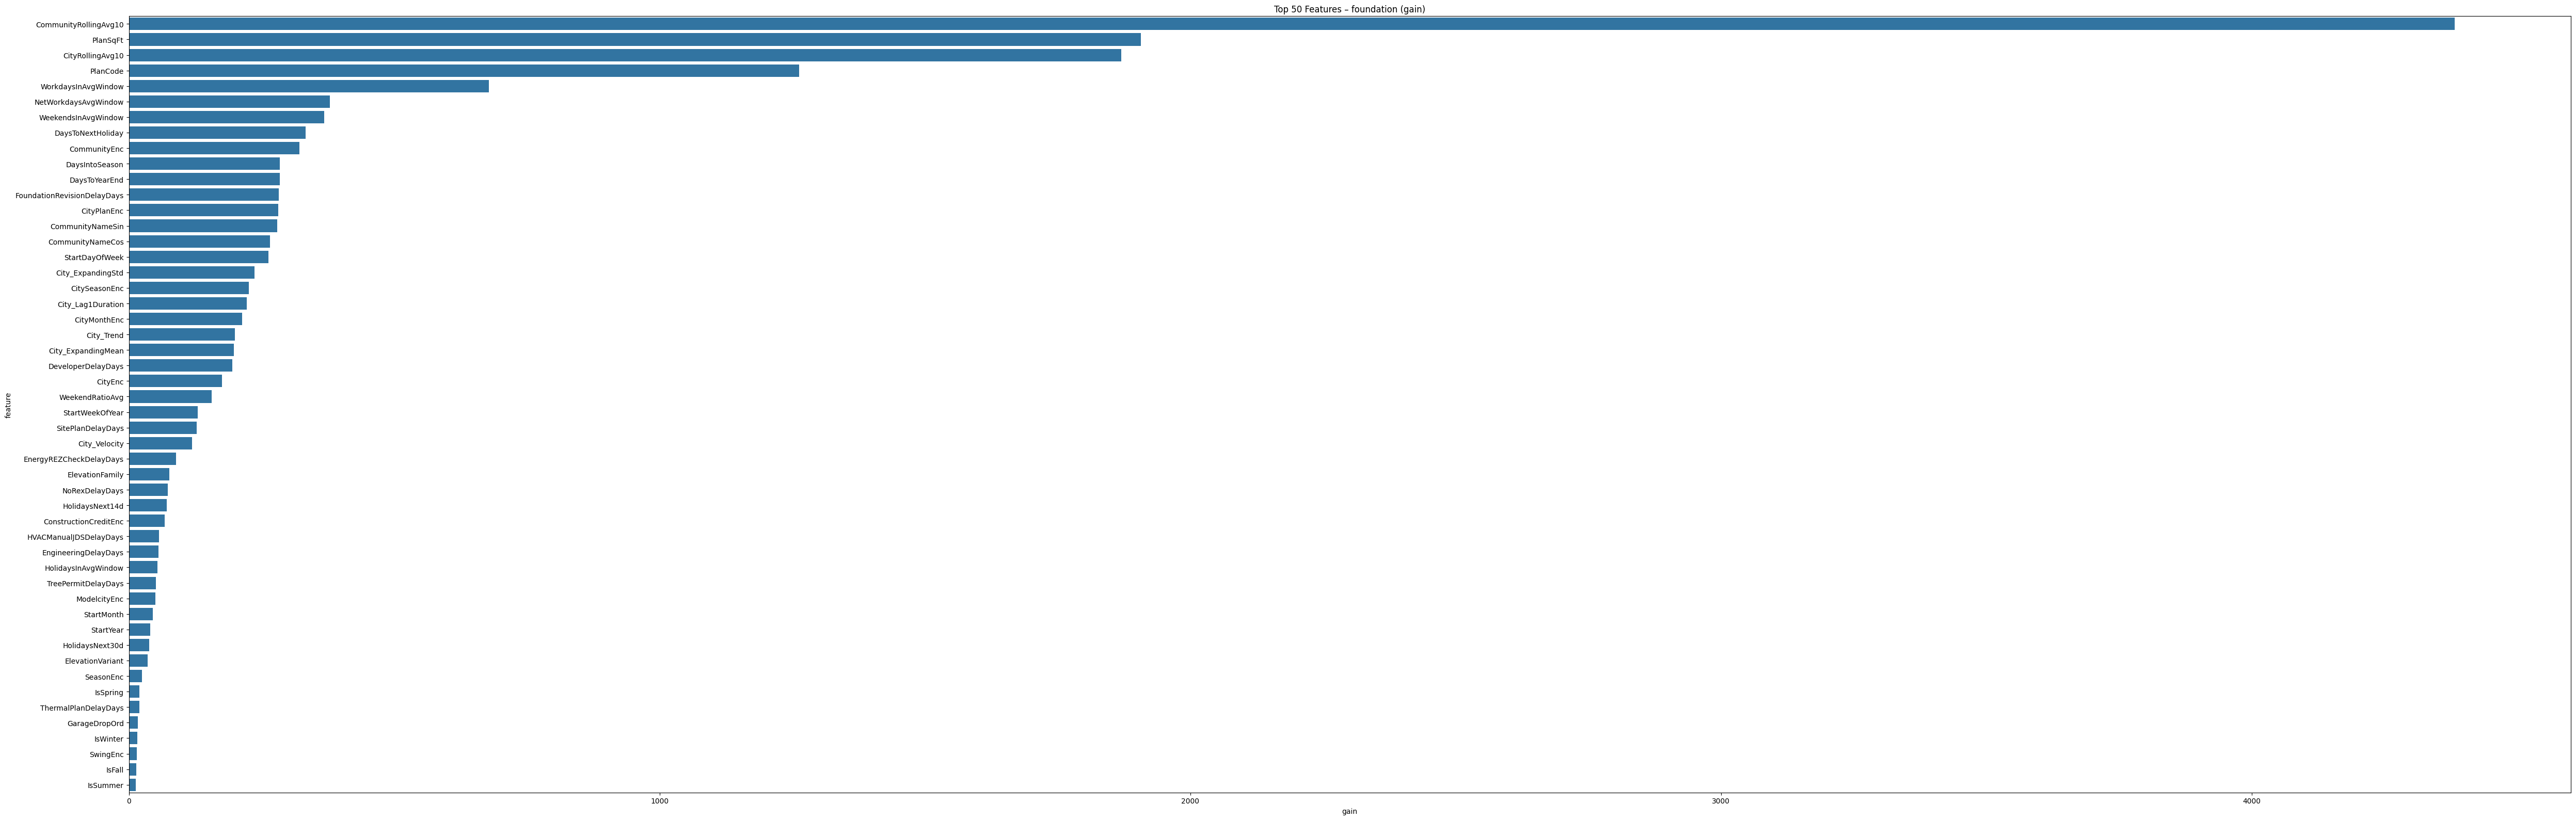

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_feature_importance(model, feature_names, stage, top_n=50):
    imp = pd.DataFrame({
        'feature': feature_names,
        'gain': model.booster_.feature_importance(importance_type='gain')
    }).sort_values('gain', ascending=False).head(top_n)
    
    plt.figure(figsize=(50,16))
    sns.barplot(x='gain', y='feature', data=imp)
    plt.title(f'Top {top_n} Features – {stage} (gain)')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/feat_imp_{stage}.png')
    plt.show()

# Example for foundation stage
plot_feature_importance(final_global_models['foundation'], FEATURES, 'foundation')

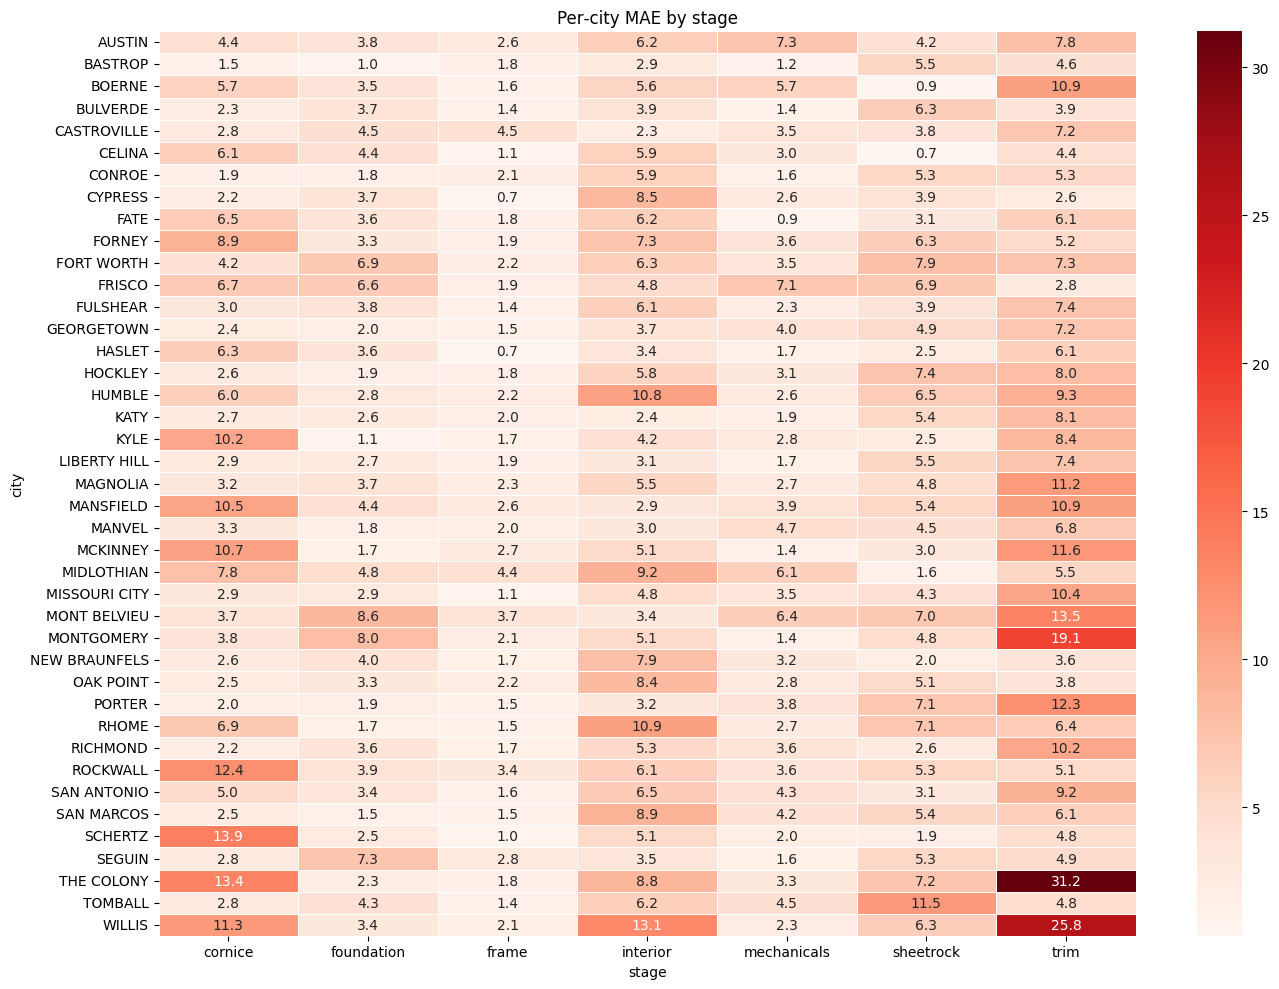

In [52]:
# Collect results from all_stage_results dict
error_df = []
for stage, res in all_stage_results.items():
    for city, metrics in res.items():
        if city == 'global':
            continue
        error_df.append({'stage': stage, 'city': city, 'MAE': metrics['mae'], 'Bias': metrics['bias']})
error_df = pd.DataFrame(error_df)
pivot_mae = error_df.pivot(index='city', columns='stage', values='MAE')
plt.figure(figsize=(14,10))
sns.heatmap(pivot_mae, annot=True, fmt='.1f', cmap='Reds', linewidths=0.5)
plt.title('Per‑city MAE by stage')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/city_stage_mae_heatmap.png')
plt.show()